In [2]:
!pip install ultralytics imagesize -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.7 MB/s eta 0:00:00


In [3]:
!kaggle datasets download -d antoreepjana/animals-detection-images-dataset -p /kaggle/working

Dataset URL: https://www.kaggle.com/datasets/antoreepjana/animals-detection-images-dataset
License(s): CC0-1.0
100% 8.92G/8.92G [00:58<00:00, 165MB/s]



In [4]:
!unzip -q /kaggle/working/animals-detection-images-dataset.zip -d /kaggle/working/animals-detection-images-dataset

In [5]:
dataset_root = "/kaggle/working/animals-detection-images-dataset"

In [6]:
from pathlib import Path
import os

print("Các file/thư mục trong /kaggle/working:")
for p in Path("/kaggle/working").iterdir():
    print(p)

Các file/thư mục trong /kaggle/working:
/kaggle/working/animals-detection-images-dataset
/kaggle/working/animals-detection-images-dataset.zip


In [7]:
from pathlib import Path

dataset_root = Path("/kaggle/working/animals-detection-images-dataset")

print("Dataset root tồn tại không:", dataset_root.exists())

txt_files = list(dataset_root.rglob("*.txt"))

print("Số file .txt:", len(txt_files))

if txt_files:
    sample = txt_files[0]
    print("File mẫu:", sample)
    print(sample.read_text().splitlines()[:5])
else:
    print("Không thấy .txt trong dataset_root")

Dataset root tồn tại không: True
Số file .txt: 29071
File mẫu: /kaggle/working/animals-detection-images-dataset/test/Otter/Label/7f9376041f1869a6.txt
['Otter 459.24966399999994 198.99723999999998 717.2710400000001 333.49104']


In [8]:
from pathlib import Path
import shutil
import random
from PIL import Image

dataset_root = Path("/kaggle/working/animals-detection-images-dataset")
OUT_ROOT = Path("/kaggle/working/animal_yolo_fast")

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# Train nhanh cho học sinh: lấy ít ảnh trước
MAX_TRAIN = 2000
MAX_VAL = 400

random.seed(42)

if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)

def xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    x_center = ((x1 + x2) / 2) / img_w
    y_center = ((y1 + y2) / 2) / img_h
    w = (x2 - x1) / img_w
    h = (y2 - y1) / img_h
    return x_center, y_center, w, h

def find_image_by_stem(class_dir, stem):
    for ext in IMG_EXTS:
        img_path = class_dir / f"{stem}{ext}"
        if img_path.exists():
            return img_path
    return None

def prepare_split(src_split_name, dst_split_name, max_images=None):
    src_split = dataset_root / src_split_name

    out_img_dir = OUT_ROOT / "images" / dst_split_name
    out_lbl_dir = OUT_ROOT / "labels" / dst_split_name

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    label_files = list(src_split.rglob("Label/*.txt"))
    random.shuffle(label_files)

    if max_images is not None:
        label_files = label_files[:max_images]

    copied = 0
    bad = 0
    missing_image = 0

    for label_path in label_files:
        class_dir = label_path.parent.parent
        img_path = find_image_by_stem(class_dir, label_path.stem)

        if img_path is None:
            missing_image += 1
            continue

        try:
            img = Image.open(img_path)
            img_w, img_h = img.size
        except:
            bad += 1
            continue

        new_lines = []

        for line in label_path.read_text().splitlines():
            parts = line.strip().split()

            if len(parts) < 5:
                bad += 1
                continue

            # Lấy 4 số cuối: x1 y1 x2 y2
            try:
                x1, y1, x2, y2 = map(float, parts[-4:])
            except:
                bad += 1
                continue

            # Chặn bbox không vượt quá ảnh
            x1 = max(0, min(x1, img_w))
            x2 = max(0, min(x2, img_w))
            y1 = max(0, min(y1, img_h))
            y2 = max(0, min(y2, img_h))

            if x2 <= x1 or y2 <= y1:
                bad += 1
                continue

            xc, yc, w, h = xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h)

            # Gom tất cả loài thành 1 class: Animal
            new_lines.append(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

        if len(new_lines) == 0:
            bad += 1
            continue

        # Đổi tên để tránh trùng ảnh giữa các class
        new_stem = f"{class_dir.name}_{label_path.stem}"
        new_img_path = out_img_dir / f"{new_stem}{img_path.suffix.lower()}"
        new_lbl_path = out_lbl_dir / f"{new_stem}.txt"

        shutil.copy(img_path, new_img_path)
        new_lbl_path.write_text("\n".join(new_lines))

        copied += 1

    print(f"{src_split_name} -> {dst_split_name}")
    print("Copy thành công:", copied)
    print("Thiếu ảnh:", missing_image)
    print("Label lỗi:", bad)

prepare_split("train", "train", MAX_TRAIN)
prepare_split("test", "val", MAX_VAL)

train -> train
Copy thành công: 2000
Thiếu ảnh: 0
Label lỗi: 0
test -> val
Copy thành công: 400
Thiếu ảnh: 0
Label lỗi: 0


In [9]:
from pathlib import Path
import shutil
import random
from PIL import Image

dataset_root = Path("/kaggle/working/animals-detection-images-dataset")
OUT_ROOT = Path("/kaggle/working/animal_species_yolo_fast")

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# Train nhanh để dạy học sinh, lấy mỗi loài một số ảnh
MAX_TRAIN_PER_CLASS = 80
MAX_VAL_PER_CLASS = 20

random.seed(42)

if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)

# Lấy danh sách loài từ folder train/test
class_names = sorted({
    p.name
    for split in ["train", "test"]
    for p in (dataset_root / split).iterdir()
    if p.is_dir()
})

class_to_id = {name: i for i, name in enumerate(class_names)}

print("Số loài:", len(class_names))
print("Một vài loài:", class_names[:20])

def xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    x_center = ((x1 + x2) / 2) / img_w
    y_center = ((y1 + y2) / 2) / img_h
    w = (x2 - x1) / img_w
    h = (y2 - y1) / img_h
    return x_center, y_center, w, h

def find_image_by_stem(class_dir, stem):
    for ext in IMG_EXTS:
        img_path = class_dir / f"{stem}{ext}"
        if img_path.exists():
            return img_path
    return None

def prepare_split(src_split_name, dst_split_name, max_per_class):
    out_img_dir = OUT_ROOT / "images" / dst_split_name
    out_lbl_dir = OUT_ROOT / "labels" / dst_split_name

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    total_copied = 0
    total_bad = 0
    total_missing_image = 0

    src_split = dataset_root / src_split_name

    for class_dir in sorted([p for p in src_split.iterdir() if p.is_dir()]):
        class_name = class_dir.name
        class_id = class_to_id[class_name]

        label_dir = class_dir / "Label"

        if not label_dir.exists():
            continue

        label_files = list(label_dir.glob("*.txt"))
        random.shuffle(label_files)

        if max_per_class is not None:
            label_files = label_files[:max_per_class]

        class_copied = 0

        for label_path in label_files:
            img_path = find_image_by_stem(class_dir, label_path.stem)

            if img_path is None:
                total_missing_image += 1
                continue

            try:
                img = Image.open(img_path)
                img_w, img_h = img.size
            except:
                total_bad += 1
                continue

            new_lines = []

            for line in label_path.read_text().splitlines():
                parts = line.strip().split()

                if len(parts) < 5:
                    total_bad += 1
                    continue

                try:
                    x1, y1, x2, y2 = map(float, parts[-4:])
                except:
                    total_bad += 1
                    continue

                x1 = max(0, min(x1, img_w))
                x2 = max(0, min(x2, img_w))
                y1 = max(0, min(y1, img_h))
                y2 = max(0, min(y2, img_h))

                if x2 <= x1 or y2 <= y1:
                    total_bad += 1
                    continue

                xc, yc, w, h = xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h)

                # Giữ đúng loài, không gom về Animal
                new_lines.append(f"{class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

            if len(new_lines) == 0:
                total_bad += 1
                continue

            new_stem = f"{class_name}_{label_path.stem}"
            new_img_path = out_img_dir / f"{new_stem}{img_path.suffix.lower()}"
            new_lbl_path = out_lbl_dir / f"{new_stem}.txt"

            shutil.copy(img_path, new_img_path)
            new_lbl_path.write_text("\n".join(new_lines))

            class_copied += 1
            total_copied += 1

        print(f"{dst_split_name} | {class_name}: {class_copied} ảnh")

    print(f"\nTổng {dst_split_name}:")
    print("Copy thành công:", total_copied)
    print("Thiếu ảnh:", total_missing_image)
    print("Label lỗi:", total_bad)

prepare_split("train", "train", MAX_TRAIN_PER_CLASS)
prepare_split("test", "val", MAX_VAL_PER_CLASS)

Số loài: 80
Một vài loài: ['Bear', 'Brown bear', 'Bull', 'Butterfly', 'Camel', 'Canary', 'Caterpillar', 'Cattle', 'Centipede', 'Cheetah', 'Chicken', 'Crab', 'Crocodile', 'Deer', 'Duck', 'Eagle', 'Elephant', 'Fish', 'Fox', 'Frog']
train | Bear: 80 ảnh
train | Brown bear: 80 ảnh
train | Bull: 47 ảnh
train | Butterfly: 80 ảnh
train | Camel: 67 ảnh
train | Canary: 80 ảnh
train | Caterpillar: 80 ảnh
train | Cattle: 70 ảnh
train | Centipede: 80 ảnh
train | Cheetah: 80 ảnh
train | Chicken: 80 ảnh
train | Crab: 80 ảnh
train | Crocodile: 80 ảnh
train | Deer: 80 ảnh
train | Duck: 80 ảnh
train | Eagle: 80 ảnh
train | Elephant: 80 ảnh
train | Fish: 80 ảnh
train | Fox: 80 ảnh
train | Frog: 80 ảnh
train | Giraffe: 80 ảnh
train | Goat: 80 ảnh
train | Goldfish: 80 ảnh
train | Goose: 80 ảnh
train | Hamster: 64 ảnh
train | Harbor seal: 80 ảnh
train | Hedgehog: 80 ảnh
train | Hippopotamus: 76 ảnh
train | Horse: 80 ảnh
train | Jaguar: 80 ảnh
train | Jellyfish: 80 ảnh
train | Kangaroo: 80 ảnh
train | Koala

In [10]:
print("Train images:", len(list((OUT_ROOT / "images/train").glob("*"))))
print("Train labels:", len(list((OUT_ROOT / "labels/train").glob("*"))))
print("Val images:", len(list((OUT_ROOT / "images/val").glob("*"))))
print("Val labels:", len(list((OUT_ROOT / "labels/val").glob("*"))))

sample_label = list((OUT_ROOT / "labels/train").glob("*.txt"))[0]
print("Label mẫu sau convert:")
print(sample_label)
print(sample_label.read_text().splitlines()[:5])

Train images: 5954
Train labels: 5954
Val images: 1549
Val labels: 1549
Label mẫu sau convert:
/kaggle/working/animal_species_yolo_fast/labels/train/Cattle_fe56b938adfdae26.txt
['7 0.488125 0.550833 0.560000 0.511667']


In [11]:
yaml_path = "/kaggle/working/animal_species.yaml"

yaml_text = f"""
path: /kaggle/working/animal_species_yolo_fast
train: images/train
val: images/val

nc: {len(class_names)}
names:
"""

for i, name in enumerate(class_names):
    yaml_text += f"  {i}: {name}\n"

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print(open(yaml_path).read())


path: /kaggle/working/animal_species_yolo_fast
train: images/train
val: images/val

nc: 80
names:
  0: Bear
  1: Brown bear
  2: Bull
  3: Butterfly
  4: Camel
  5: Canary
  6: Caterpillar
  7: Cattle
  8: Centipede
  9: Cheetah
  10: Chicken
  11: Crab
  12: Crocodile
  13: Deer
  14: Duck
  15: Eagle
  16: Elephant
  17: Fish
  18: Fox
  19: Frog
  20: Giraffe
  21: Goat
  22: Goldfish
  23: Goose
  24: Hamster
  25: Harbor seal
  26: Hedgehog
  27: Hippopotamus
  28: Horse
  29: Jaguar
  30: Jellyfish
  31: Kangaroo
  32: Koala
  33: Ladybug
  34: Leopard
  35: Lion
  36: Lizard
  37: Lynx
  38: Magpie
  39: Monkey
  40: Moths and butterflies
  41: Mouse
  42: Mule
  43: Ostrich
  44: Otter
  45: Owl
  46: Panda
  47: Parrot
  48: Penguin
  49: Pig
  50: Polar bear
  51: Rabbit
  52: Raccoon
  53: Raven
  54: Red panda
  55: Rhinoceros
  56: Scorpion
  57: Sea lion
  58: Sea turtle
  59: Seahorse
  60: Shark
  61: Sheep
  62: Shrimp
  63: Snail
  64: Snake
  65: Sparrow
  66: Spide

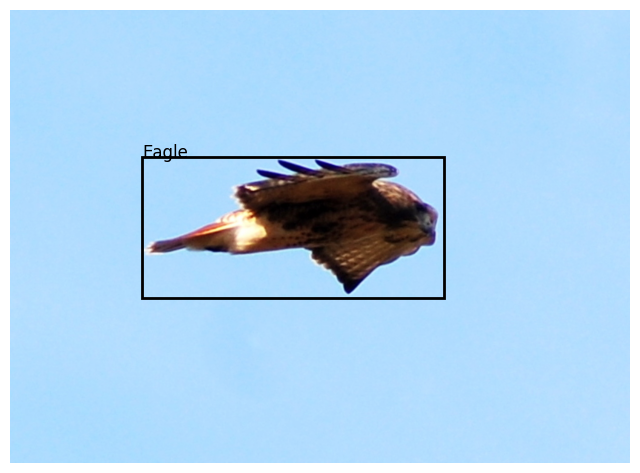

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

img_path = list((OUT_ROOT / "images/train").glob("*"))[0]
lbl_path = OUT_ROOT / "labels/train" / f"{img_path.stem}.txt"

img = Image.open(img_path)
img_w, img_h = img.size

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)

for line in lbl_path.read_text().splitlines():
    cls_id, xc, yc, w, h = line.split()
    cls_id = int(cls_id)
    xc, yc, w, h = map(float, [xc, yc, w, h])

    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    bw = w * img_w
    bh = h * img_h

    rect = patches.Rectangle((x1, y1), bw, bh, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x1, y1, class_names[cls_id], fontsize=12)

ax.axis("off")
plt.show()

In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data = "/kaggle/working/animal_species.yaml",
    epochs=10,
    imgsz=416,
    batch=16,
    device=0,
    name="animal_species_yolo8n_fast"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/animal_species.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c6a857664b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024

In [15]:
# 1. Tải code về (Lúc này trên Github của cậu hoàn toàn không có file weights nặng nào)
!git clone https://github.com/của-Vịt/biao_chou_study.git
%cd biao_chou_study

# 2. Cài đặt thư viện gdown phục vụ việc tải từ Drive
!pip install gdown

# 3. Tạo một ảnh test bất kỳ
!wget -O test.jpg https://images.unsplash.com/photo-1513836279014-a89f7a76ae86

# 4. Chạy file run.py
!python run.py --source test.jpg

Cloning into 'biao_chou_study'...
fatal: unable to access 'https://github.com/của-Vịt/biao_chou_study.git/': The requested URL returned error: 400
[Errno 2] No such file or directory: 'biao_chou_study'
/content/biao_chou_study
--2026-06-21 15:40:16--  https://images.unsplash.com/photo-1513836279014-a89f7a76ae86
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8116973 (7.7M) [image/jpeg]
Saving to: ‘test.jpg’

test.jpg            100%[===================>]   7.74M  --.-KB/s    in 0.07s   

2026-06-21 15:40:17 (108 MB/s) - ‘test.jpg’ saved [8116973/8116973]

python3: can't open file '/content/biao_chou_study/run.py': [Errno 2] No such file or directory
